In [ ]:
import os
os.chdir(r'C:\Users\johnpaul\fraudguard-africa')
print(os.getcwd())

C:\Users\johnpaul\fraudguard-africa


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ====================== LOAD THE DATA ======================
print("Loading dataset...\n")
df = pd.read_csv('data/PS_20174392719_1491204439457_log.csv')

print(f"Dataset Shape: {df.shape}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB\n")

Loading dataset...

Dataset Shape: (6362620, 11)
Memory Usage: 1598.19 MB



In [4]:
# ====================== BASIC INFORMATION ======================
print("=== Columns ===")
print(df.columns.tolist())

print("\n=== First 5 Rows ===")
print(df.head())

print("\n=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Columns ===
['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

=== First 5 Rows ===
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1         


=== Target Variable: isFraud ===
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud Percentage: 0.1291%
Non-Fraud Percentage: 99.8709%


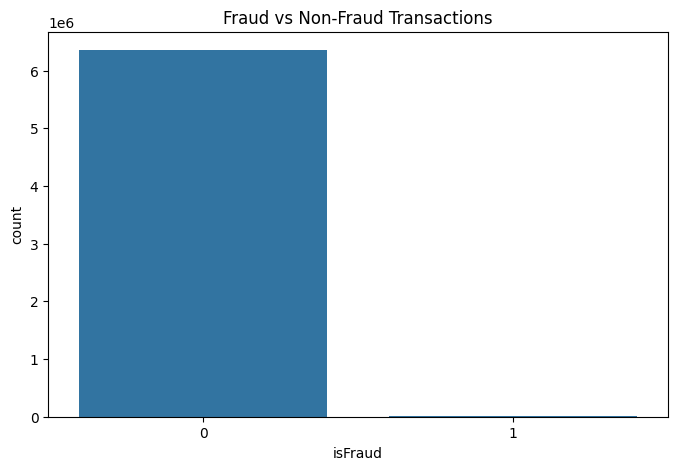

In [5]:
# ====================== FRAUD DISTRIBUTION ======================
print("\n=== Target Variable: isFraud ===")
fraud_counts = df['isFraud'].value_counts()
print(fraud_counts)
print(f"\nFraud Percentage: {fraud_counts[1]/len(df)*100:.4f}%")
print(f"Non-Fraud Percentage: {fraud_counts[0]/len(df)*100:.4f}%")

# Visualization
plt.figure(figsize=(8,5))
sns.countplot(x='isFraud', data=df)
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()


=== Transaction Types ===
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


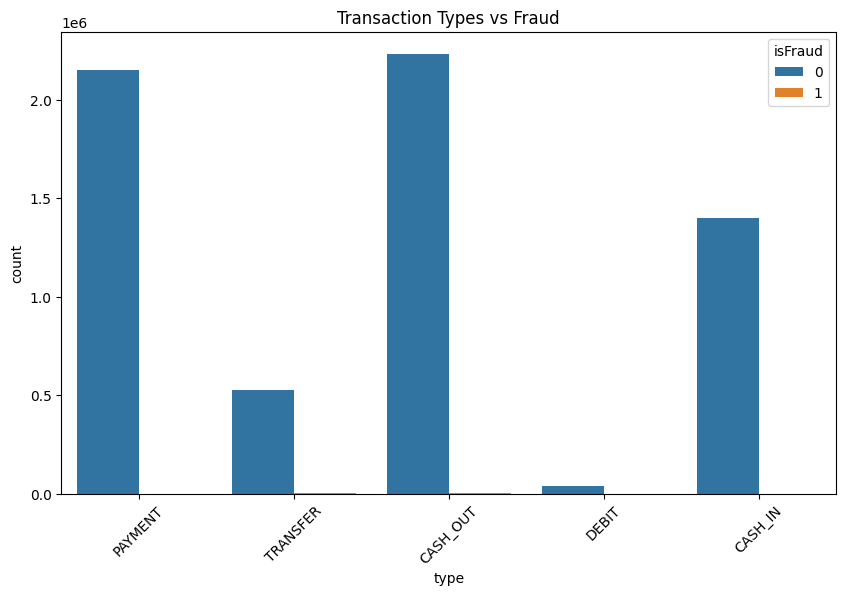

In [6]:
# ====================== TRANSACTION TYPES ======================
print("\n=== Transaction Types ===")
print(df['type'].value_counts())

plt.figure(figsize=(10,6))
sns.countplot(x='type', hue='isFraud', data=df)
plt.title('Transaction Types vs Fraud')
plt.xticks(rotation=45)
plt.show()


=== Amount Statistics ===
count    6.362620e+06
mean     1.798619e+05
std      6.038582e+05
min      0.000000e+00
25%      1.338957e+04
50%      7.487194e+04
75%      2.087215e+05
max      9.244552e+07
Name: amount, dtype: float64


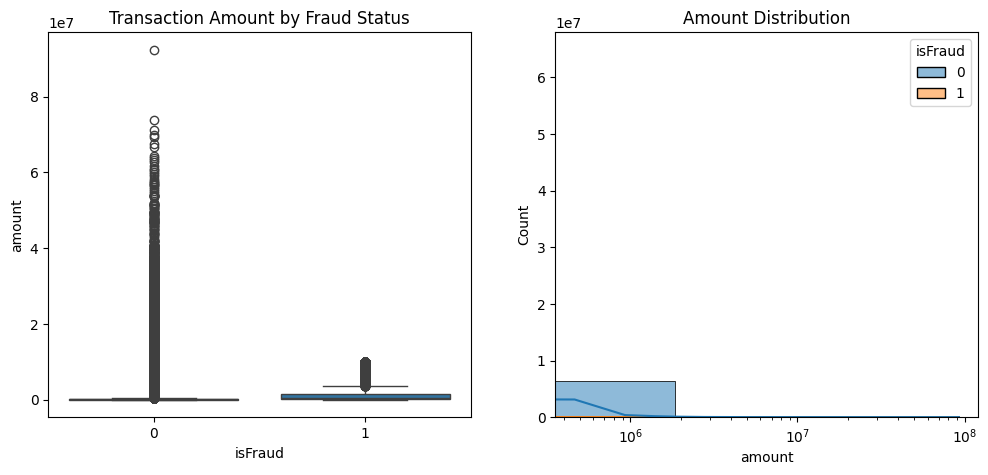

In [7]:
# ====================== AMOUNT STATISTICS ======================
print("\n=== Amount Statistics ===")
print(df['amount'].describe())

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title('Transaction Amount by Fraud Status')

plt.subplot(1,2,2)
sns.histplot(data=df, x='amount', hue='isFraud', bins=50, kde=True)
plt.title('Amount Distribution')
plt.xscale('log')
plt.show()

In [8]:
# ====================== DEEPER ANALYSIS ======================

# 1. Fraud by Transaction Type
print("\n=== Fraud Rate by Transaction Type ===")
fraud_by_type = df.groupby('type')['isFraud'].agg(['count', 'sum', 'mean'])
fraud_by_type.columns = ['Total', 'Fraud', 'Fraud_Rate']
fraud_by_type['Fraud_Rate'] = fraud_by_type['Fraud_Rate'] * 100
print(fraud_by_type.sort_values('Fraud_Rate', ascending=False))


=== Fraud Rate by Transaction Type ===
            Total  Fraud  Fraud_Rate
type                                
TRANSFER   532909   4097    0.768799
CASH_OUT  2237500   4116    0.183955
CASH_IN   1399284      0    0.000000
DEBIT       41432      0    0.000000
PAYMENT   2151495      0    0.000000



=== Step (Time) Analysis ===
count    6.362620e+06
mean     2.433972e+02
std      1.423320e+02
min      1.000000e+00
25%      1.560000e+02
50%      2.390000e+02
75%      3.350000e+02
max      7.430000e+02
Name: step, dtype: float64


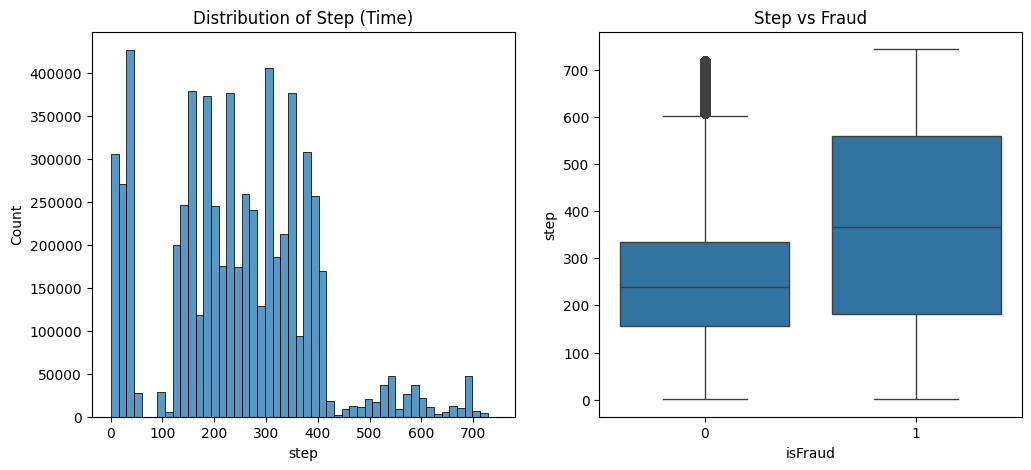

In [9]:
# 2. Step (Time) Analysis
print("\n=== Step (Time) Analysis ===")
print(df['step'].describe())

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['step'], bins=50)
plt.title('Distribution of Step (Time)')

plt.subplot(1,2,2)
sns.boxplot(x='isFraud', y='step', data=df)
plt.title('Step vs Fraud')
plt.show()

In [10]:
# 3. Customer Analysis (nameOrig and nameDest)
print("\n=== Customer Analysis ===")
print("Unique Origin Customers:", df['nameOrig'].nunique())
print("Unique Destination Customers:", df['nameDest'].nunique())

# Fraud rate when same customer appears multiple times
print("\n=== Is Flagged Fraud Column ===")
print(df['isFlaggedFraud'].value_counts())
print("Fraud cases where isFlaggedFraud = 1:", len(df[(df['isFraud']==1) & (df['isFlaggedFraud']==1)]))

# 4. Amount Analysis for Fraud vs Non-Fraud
print("\n=== Amount Statistics by Fraud ===")
print(df.groupby('isFraud')['amount'].describe())


=== Customer Analysis ===
Unique Origin Customers: 6353307
Unique Destination Customers: 2722362

=== Is Flagged Fraud Column ===
isFlaggedFraud
0    6362604
1         16
Name: count, dtype: int64
Fraud cases where isFlaggedFraud = 1: 16

=== Amount Statistics by Fraud ===
             count          mean           std   min         25%        50%  \
isFraud                                                                       
0        6354407.0  1.781970e+05  5.962370e+05  0.01   13368.395   74684.72   
1           8213.0  1.467967e+06  2.404253e+06  0.00  127091.330  441423.44   

                75%          max  
isFraud                           
0         208364.76  92445516.64  
1        1517771.48  10000000.00  


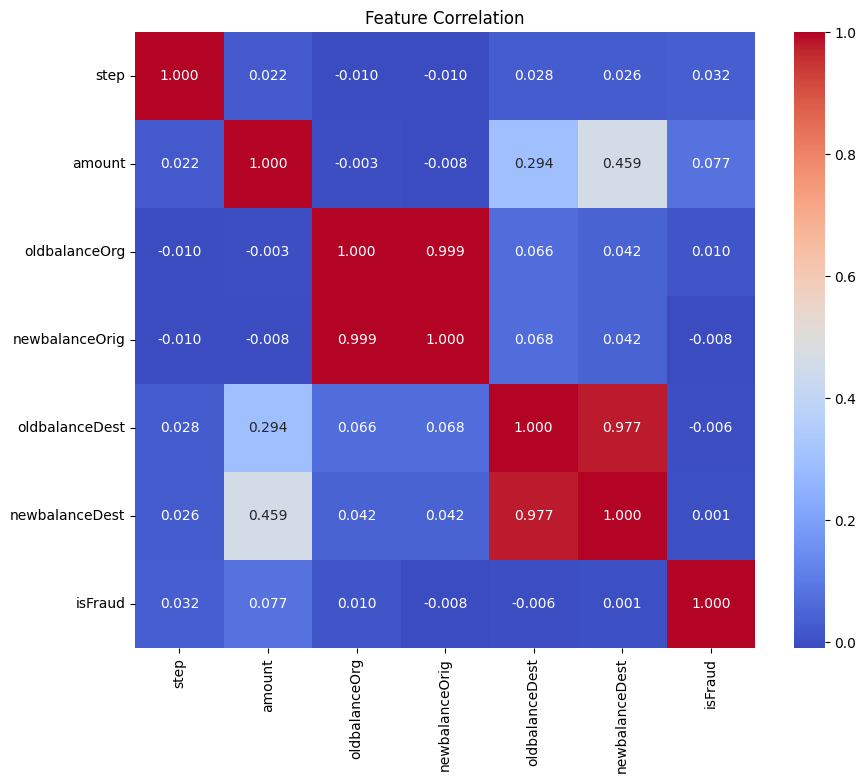

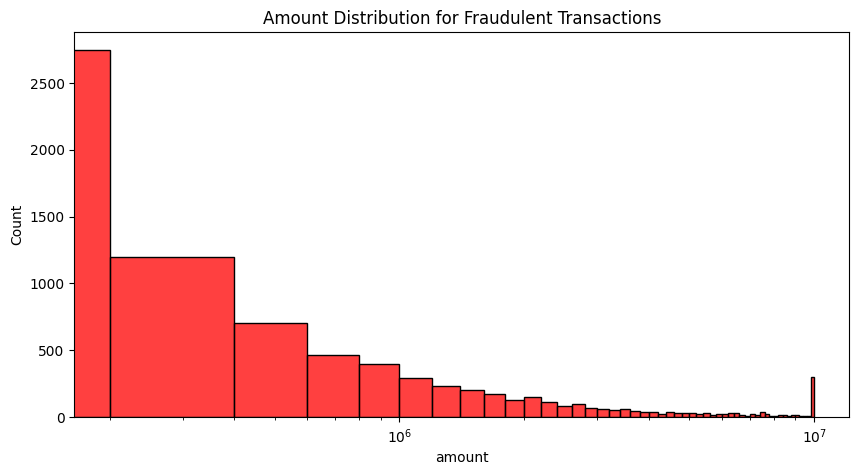


=== Key Takeaways ===
1. Dataset is highly imbalanced (0.129% fraud)
2. Cash Out transactions are the most dangerous
3. Fraud tends to involve higher or specific amounts
4. We have time dimension (step) to use


In [11]:
# Correlation Analysis (Numerical Features)
numerical_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
                  'oldbalanceDest', 'newbalanceDest', 'isFraud']
correlation = df[numerical_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Feature Correlation')
plt.show()

# Fraud Amount Distribution
plt.figure(figsize=(10,5))
sns.histplot(data=df[df['isFraud']==1], x='amount', bins=50, color='red')
plt.title('Amount Distribution for Fraudulent Transactions')
plt.xscale('log')
plt.show()

print("\n=== Key Takeaways ===")
print("1. Dataset is highly imbalanced (0.129% fraud)")
print("2. Cash Out transactions are the most dangerous")
print("3. Fraud tends to involve higher or specific amounts")
print("4. We have time dimension (step) to use")